# Challenge: Missing Values

| [![leader-badge]][leader-url] |
|:-:|

[leader-badge]: https://img.shields.io/badge/leaderboard-grey?style=for-the-badge&logoColor=white

[leader-url]: https://github.com/climet-eu/compression-lab-notebooks/issues/47

You are challenged to find a compressor that produces the highest compression ratio when compressing the provided satellite observation example dataset with an absolute error bound. The dataset contains missing values. The compressor must preserve the missing values and must not violate the error bound.

This product includes software produced by UChicago Argonne, LLC under Contract No. DE-AC02-06CH11357 with the Department of Energy.

In [1]:
import sys

sys.path.insert(0, "..")

In [2]:
import h5netcdf
import numpy as np
import xarray as xr
from upath import UPath

[pyodide]: Loading fsspec, h5netcdf, numpy, pandas, pathlib_abc, python-dateutil, pytz, six, tzdata, universal_pathlib, xarray
[pyodide]: Loaded fsspec, h5netcdf, numpy, pandas, pathlib_abc, python-dateutil, pytz, six, tzdata, universal_pathlib, xarray
[pyodide]: Loading h5py
[pyodide]: Loaded h5py
[pyodide]: Loading pyfive, typing_extensions
[pyodide]: Loaded pyfive, typing_extensions
[pyodide]: Loading pyarrow, pyodide-unix-timezones
[pyodide]: Loaded pyarrow, pyodide-unix-timezones
[pyodide]: Loading cloudpickle
[pyodide]: Loaded cloudpickle
[pyodide]: Loading Bottleneck
[pyodide]: Loaded Bottleneck
[pyodide]: Loading cftime
[pyodide]: Loaded cftime
[pyodide]: Loading PyYAML, click, dask, locket, partd, toolz
[pyodide]: Loaded PyYAML, click, dask, locket, partd, toolz
[pyodide]: Loading lz4
[pyodide]: Loaded lz4
[pyodide]: Memory usage has grown to 107.9MiB (from 43.2MiB) for this notebook
[pyodide]: Loaded 90 new dynamic libraries (93 total for this notebook)


In [3]:
# URL of S3 bucket
BASE_URL = "https://object-store.os-api.cci1.ecmwf.int/esiwacebucket"

data = UPath(BASE_URL)

In [4]:
import earthkit.plots

from utils import open_remote_dataset, quickplot

[pyodide]: Loading Cartopy, Jinja2, Markdown, MarkupSafe, Pint, adjustText, array-api-compat, attrs, cffi, cfgrib, contourpy, cycler, deprecation, earthkit-data, earthkit-plots, earthkit-utils, eccodes, eccodeslib, eckit, eckitlib, entrypoints, filelock, findlibs, flexcache, flexparser, fonttools, jsonschema, jsonschema-specifications, kiwisolver, lru-dict, matplotlib, multiurl, narwhals, netCDF4, pdbufr, pillow, platformdirs, plotly, pycparser, pyparsing, pyproj, pyshp, referencing, rpds-py, scipy, shapely, tqdm
[pyodide]: Loaded Cartopy, Jinja2, Markdown, MarkupSafe, Pint, adjustText, array-api-compat, attrs, cffi, cfgrib, contourpy, cycler, deprecation, earthkit-data, earthkit-plots, earthkit-utils, eccodes, eccodeslib, eckit, eckitlib, entrypoints, filelock, findlibs, flexcache, flexparser, fonttools, jsonschema, jsonschema-specifications, kiwisolver, lru-dict, matplotlib, multiurl, narwhals, netCDF4, pdbufr, pillow, platformdirs, plotly, pycparser, pyparsing, pyproj, pyshp, refere

## Challenge Configuration (do not edit)

In [5]:
# Load the data
ds = open_remote_dataset(
    data / "HOAPS" / "HOAPS_2020-08_6-hourly.nc",
    engine="h5netcdf",
    decode_timedelta=True,
)
da = ds["wvpa"].sel(time=slice("2020-08-01", "2020-08-07"))

[pyodide]: Loading ipyfilite, ipywidgets, jupyterlab_widgets
[pyodide]: Loaded ipyfilite, ipywidgets, jupyterlab_widgets
[pyodide]: Loading WebOb, beautifulsoup4, cattrs, legacy-cgi, lxml, pydap, requests-cache, soupsieve, url-normalize
[pyodide]: Loaded WebOb, beautifulsoup4, cattrs, legacy-cgi, lxml, pydap, requests-cache, soupsieve, url-normalize
[pyodide]: Loading Deprecated, donfig, google-crc32c, numcodecs, wrapt, zarr
[pyodide]: Loaded Deprecated, donfig, google-crc32c, numcodecs, wrapt, zarr
[pyodide]: Loading arraypartition, cfapyx
[pyodide]: Loaded arraypartition, cfapyx


/lib/python3.14/site-packages/earthkit/data/core/config.py:287: UserWarning: only soft file lock is available
  from filelock import FileLock


[pyodide]: Loading MetPy, pooch
[pyodide]: Loaded MetPy, pooch
[pyodide]: Loading uncertainties
[pyodide]: Loaded uncertainties
[pyodide]: Loading click-plugins, cligj, fiona
[pyodide]: Loaded click-plugins, cligj, fiona
[pyodide]: Loading boto3, botocore, jmespath, s3transfer
[pyodide]: Loaded boto3, botocore, jmespath, s3transfer
[pyodide]: Loading kerchunk, ujson
[pyodide]: Loaded kerchunk, ujson
[pyodide]: Loading crc32c
[pyodide]: Loaded crc32c
[pyodide]: Loading msgpack
[pyodide]: Loaded msgpack
[pyodide]: Memory usage has grown to 268.7MiB (from 129.5MiB) for this notebook
[pyodide]: Loaded 127 new dynamic libraries (227 total for this notebook)


In [6]:
eb_abs_check = 1  # kg m-2

## Compressor Configuration (edit here)

In [7]:
eb_abs = 1  # kg m-2

In [8]:
from numcodecs_wasm_zfp import Zfp

codec = Zfp(mode="fixed-accuracy", tolerance=eb_abs, non_finite="allow-unsafe")

[pyodide]: Loading leb128, numcodecs-combinators, numcodecs-observers, numcodecs_wasm, numcodecs_wasm_zfp
[pyodide]: Loaded leb128, numcodecs-combinators, numcodecs-observers, numcodecs_wasm, numcodecs_wasm_zfp
[pyodide]: Memory usage has grown to 322.4MiB (from 268.7MiB) for this notebook
[pyodide]: Loaded 1 new dynamic library (228 total for this notebook)


In [9]:
print(codec.get_config())

{'id': 'zfp.rs', 'mode': 'fixed-accuracy', 'tolerance': 1.0, 'non_finite': 'allow-unsafe', '_version': '0.2.0'}


## Challenge Evaluation (do not edit)

In [10]:
# encode and decode the data
da_enc = codec.encode(da.values)
da_dec = da.copy(data=codec.decode(da_enc, out=np.empty(da.shape, dtype=da.dtype)))

[pyodide]: Memory usage has grown to 386.9MiB (from 322.4MiB) for this notebook


/lib/python3.14/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


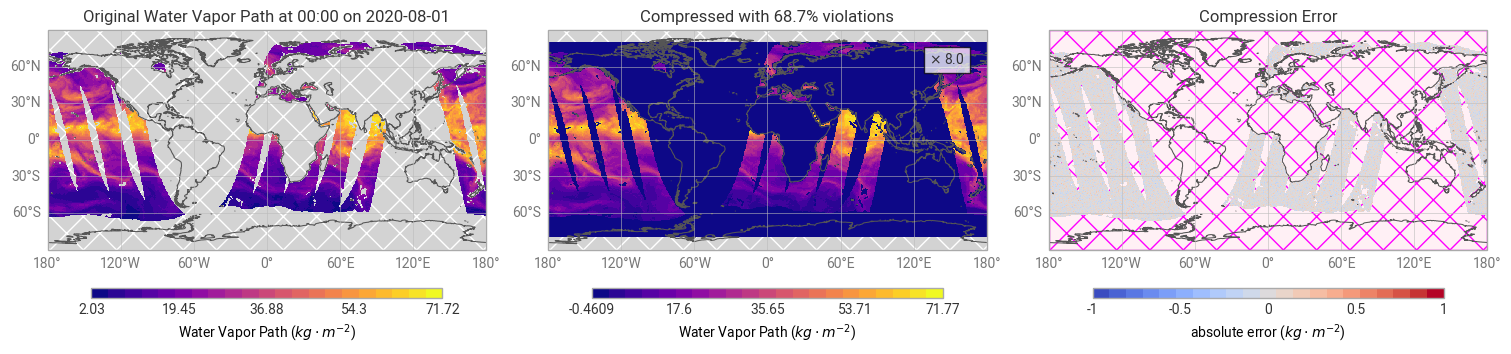

[pyodide]: Memory usage has grown to 557.2MiB (from 386.9MiB) for this notebook
[pyodide]: Loaded 2 new dynamic libraries (230 total for this notebook)


In [11]:
# plot a comparison figure
fig = earthkit.plots.Figure(
    figsize=(15, 4),
    rows=1,
    columns=3,
)

# violation if
# (a) the absolute error bound is exceeded
# (b) missing NaN values are not preserved
violations = np.mean(
    xr.where(
        np.isnan(da),
        ~np.isnan(da_dec),
        ~(np.abs(da_dec - da) <= eb_abs_check),
    )
)
violations = (
    0
    if violations == 0
    else np.format_float_positional(100 * violations, precision=1, min_digits=1) + "%"
)
if violations == "0.0%":
    violations = "<0.05%"

quickplot(da, fig.add_map(0, 0), title="Original {default_title}")
quickplot(
    da_dec,
    fig.add_map(0, 1),
    title=f"Compressed with {violations} violations",
    cr=da.nbytes / np.array(da_enc).nbytes,
)
quickplot(
    xr.where(np.isnan(da) & np.isnan(da_dec), 0, da_dec - da).assign_attrs(
        long_name="absolute error", units=da.units
    ),
    fig.add_map(0, 2),
    error=True,
    vrange=(-eb_abs_check, eb_abs_check),
    title="Compression Error",
)

fig.show()